In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Defend a claim and prepare a release

Day 28 · Chapter 15 · CPU worked notebook

Read Chapter15 section15.9 and Chapter1's evidence rules. No external publication occurs here.

Predict: should a course be called empirically validated if its CPU notebooks execute but the intended model-scale comparison was never run? Write a bounded claim before running.

Saved reference preview from the bounded CPU reference execution. It is a fixed result; run the cells to regenerate figures after changing controls. Make the prediction above before inspecting the preview.

![Saved reference 1: defense and release gate](../figures/chapter-15/day-28-01_defense_and_release_gate-01.png)

In [2]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "dongxi_llms").is_dir())
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (8, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
# CPU only. Local original fixtures; no checkpoint/network/server needed.


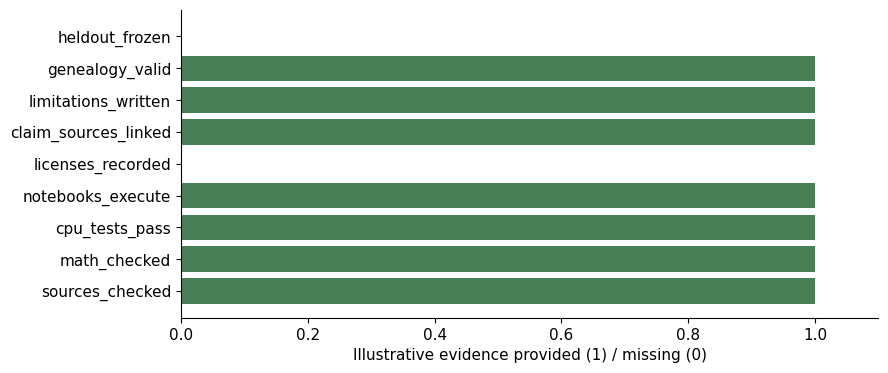

{'ready': False, 'missing': ['licenses_recorded', 'heldout_frozen'], 'external_publication': 'requires a separate user instruction'}


In [3]:
from dongxi_llms.distillation_lab import release_gate
evidence = {"sources_checked": True, "math_checked": True, "cpu_tests_pass": True,
            "notebooks_execute": True, "licenses_recorded": False,
            "claim_sources_linked": True, "limitations_written": True,
            "genealogy_valid": True, "heldout_frozen": False}
gate = release_gate(evidence)
fig, ax = plt.subplots(figsize=(9, 4))
names = list(evidence)
values = [int(evidence[name]) for name in names]
ax.barh(names, values, color=["#497f56" if x else "#b87448" for x in values])
ax.set(xlabel="Illustrative evidence provided (1) / missing (0)", xlim=(0,1.1))
plt.show()
print(gate)

Reading guide: these booleans are an illustrative case, not the actual repository release audit. The gate identifies missing evidence rather than inventing it.

Exercise: write a claim that CPU mechanisms justify and one claim requiring Qwen measurements. Fix the fixture only after stating what external evidence each missing item would need.

In [4]:
# Reference explanation, represented as reviewable claims rather than fabricated scores.
bounded_claim = "The selected objective, detach boundaries and tiny decoder path execute in the tested CPU environment."
unsupported_claim = "Qwen3-0.6B's held-out reasoning improves after this recipe."
print("Supported mechanism claim:", bounded_claim)
print("Requires measured Qwen report:", unsupported_claim)
print("Missing evidence:", gate["missing"])
assert not gate["ready"]
# A complete BOOLEAN fixture demonstrates gate behavior only.
complete_fixture = {key: True for key in evidence}
assert release_gate(complete_fixture)["ready"]
print("Complete fixture passes structurally; it is not proof that real evidence exists.")

Supported mechanism claim: The selected objective, detach boundaries and tiny decoder path execute in the tested CPU environment.
Requires measured Qwen report: Qwen3-0.6B's held-out reasoning improves after this recipe.
Missing evidence: ['licenses_recorded', 'heldout_frozen']
Complete fixture passes structurally; it is not proof that real evidence exists.


Defense prompt: explain target → data → architecture → objective → measured change → cost → failure → next experiment. Attach real report locations and name absent runs. Controlled change: remove one real acceptance check and explain which claim becomes weaker.

Evidence boundary: preparing a release candidate does not publish it or establish learner mastery. Model cards must retain negative results and unexecuted pathways.